# Credit Risk Analysis – Exploratory Data Analysis (EDA)
### Prepared by: Krishna Priya

In [72]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("loan_database.db")
df = pd.read_sql("SELECT * FROM processed_loans", conn)

df.head()

,loanId,memberId,date,purpose,isJointApplication,loanAmount,term,interestRate,monthlyPayment,grade,loanStatus
0,1888978,2305095,12/10/2014,debtconsolidation,0.0,25190.0,60 months,6.25,490.0,E3,Current
1,1299695,2610493,9/15/2014,debtconsolidation,0.0,21189.0,60 months,10.49,455.0,B3,Current
2,1875016,2491679,9/11/2014,debtconsolidation,0.0,29908.0,60 months,9.11,622.0,B2,Current
3,1440478,2092798,4/22/2016,homeimprovement,0.0,13053.0,48 months,11.89,343.0,B3,Current
4,1124634,2633077,2/3/2016,debtconsolidation,0.0,24613.0,60 months,15.13,587.0,A3,Current


## 1. Dataset Overview

In [73]:
df.shape

(51799, 11)

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51799 entries, 0 to 51798
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loanId              51799 non-null  int64  
 1   memberId            51799 non-null  int64  
 2   date                51798 non-null  object 
 3   purpose             51798 non-null  object 
 4   isJointApplication  51799 non-null  float64
 5   loanAmount          51799 non-null  float64
 6   term                51220 non-null  object 
 7   interestRate        51799 non-null  float64
 8   monthlyPayment      51799 non-null  float64
 9   grade               51798 non-null  object 
 10  loanStatus          51798 non-null  object 
dtypes: float64(4), int64(2), object(5)
memory usage: 4.3+ MB


In [75]:
df.describe()

,loanId,memberId,isJointApplication,loanAmount,interestRate,monthlyPayment
count,5.179900e+04,5.179900e+04,51799.000000,51799.000000,51799.000000,51799.000000
mean,1.448858e+06,2.450263e+06,0.050660,20658.816817,10.992477,552.624059
std,2.601026e+05,2.603807e+05,0.218252,4703.907200,3.906587,165.155808
min,1.000027e+06,2.200000e+01,0.000000,1908.000000,4.020000,44.000000
25%,1.223720e+06,2.225344e+06,0.000000,17502.000000,8.000000,434.000000
50%,1.448493e+06,2.449336e+06,0.000000,20654.000000,10.480000,533.000000
75%,1.674271e+06,2.674983e+06,0.000000,23754.500000,13.460000,654.000000
max,1.899994e+06,2.899969e+06,1.000000,41769.000000,31.700000,1524.000000


## 2. Target Variable Analysis (loanStatus)

In [76]:
df['loanStatus'].value_counts()

loanStatus
Current    46640
Default     5158
Name: count, dtype: int64

In [77]:
df['loanStatus'].value_counts(normalize=True)

loanStatus
Current    0.900421
Default    0.099579
Name: proportion, dtype: float64

## 3. Univariate Analysis – Numeric Features

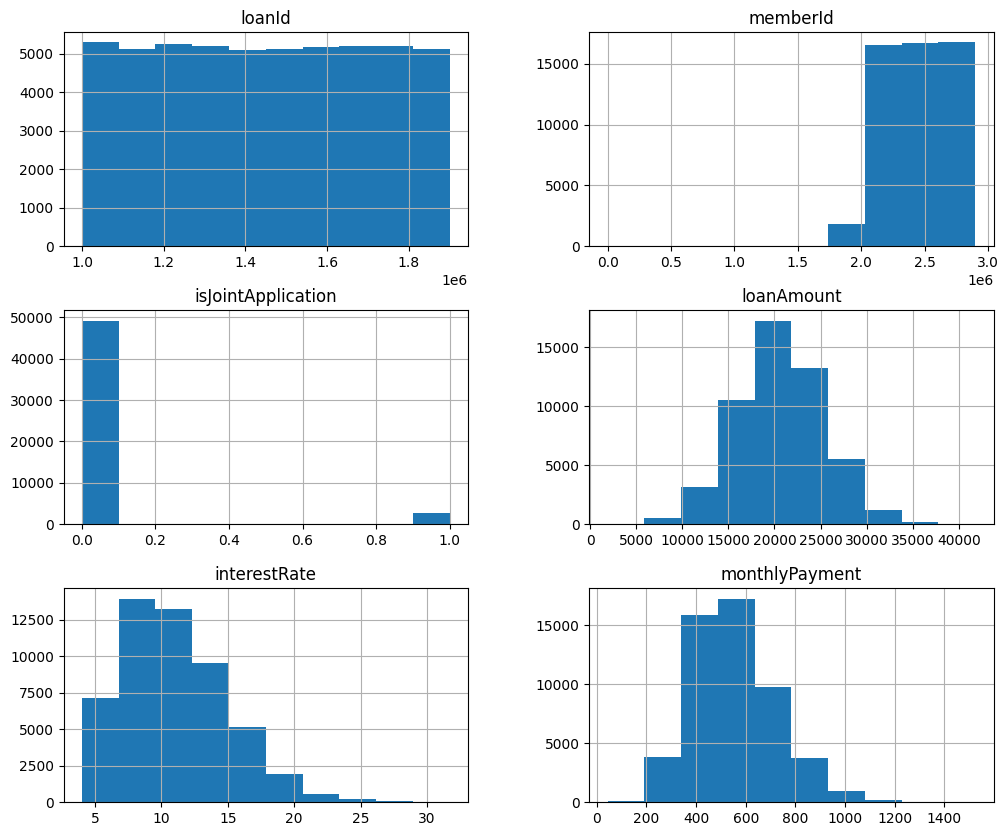

In [78]:
import matplotlib.pyplot as plt

df.hist(figsize=(12,10))
plt.show()

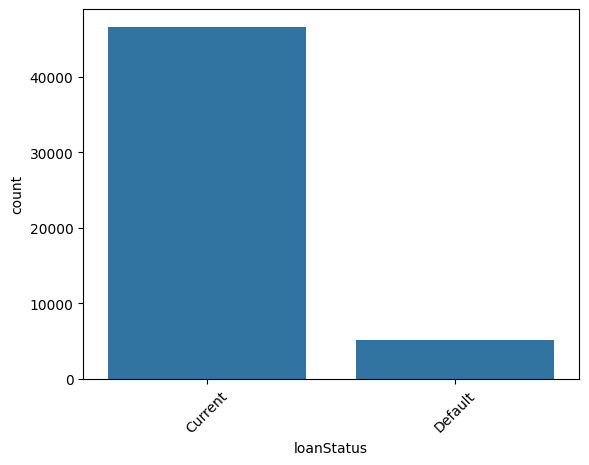

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loanStatus', data=df)
plt.xticks(rotation=45)
plt.show()

## 4. Univariate Analysis – Categorical Features

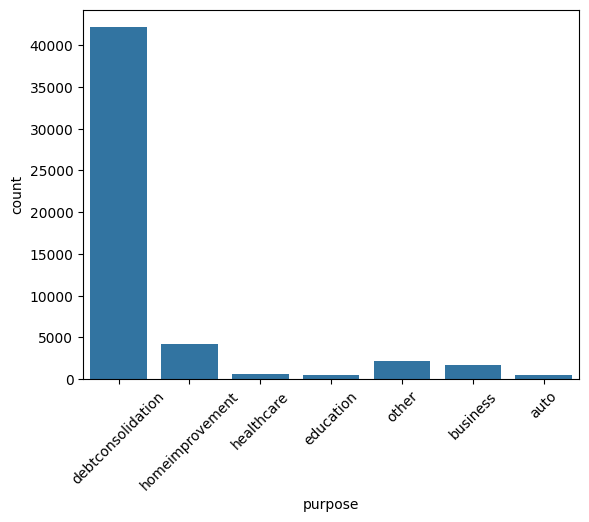

In [80]:
sns.countplot(x='purpose', data=df)
plt.xticks(rotation=45)
plt.show()

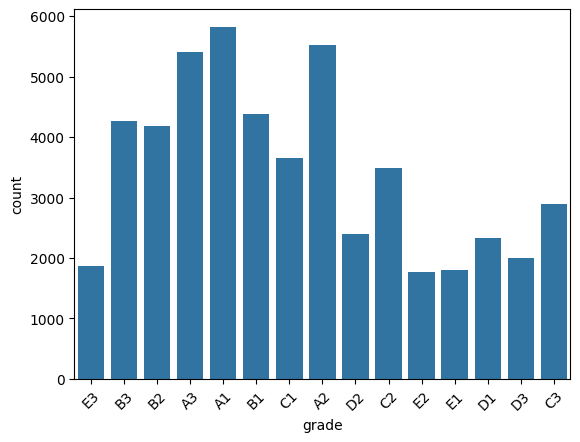

In [81]:
sns.countplot(x='grade', data=df)
plt.xticks(rotation=45)
plt.show()

## 5. Correlation Analysis

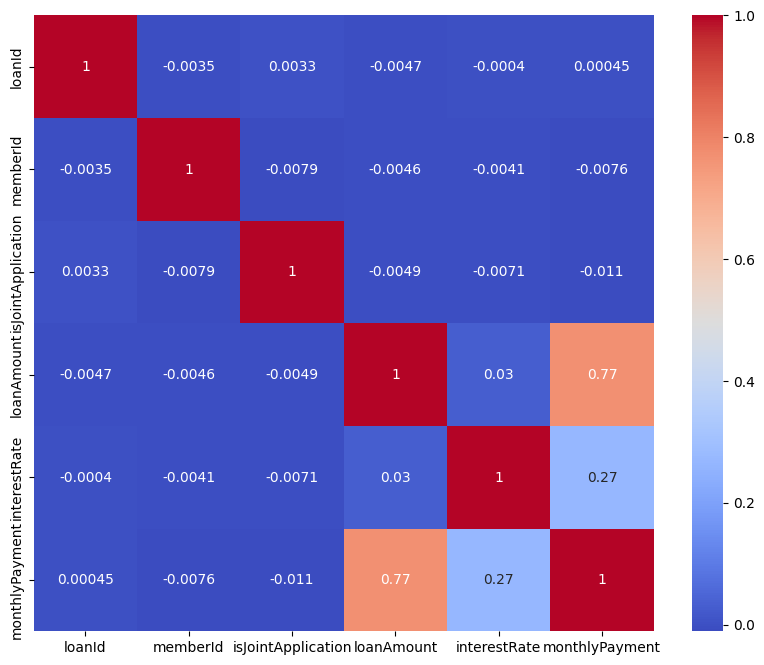

In [82]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

### Observations:

• Strong positive correlation (0.77) between loanAmount and monthlyPayment.  
• Moderate positive correlation (0.27) between interestRate and monthlyPayment.  
• No severe multicollinearity observed among numeric variables.

## 6. Default vs Feature Analysis

### Loan Amount vs Loan Status

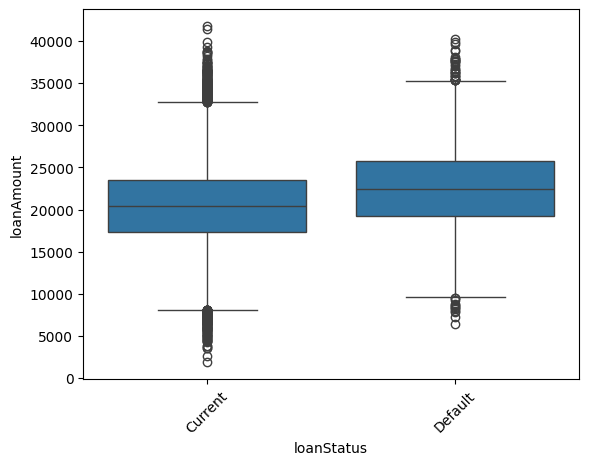

In [83]:
sns.boxplot(x='loanStatus', y='loanAmount', data=df)
plt.xticks(rotation=45)
plt.show()

### Interest Rate vs Loan Status

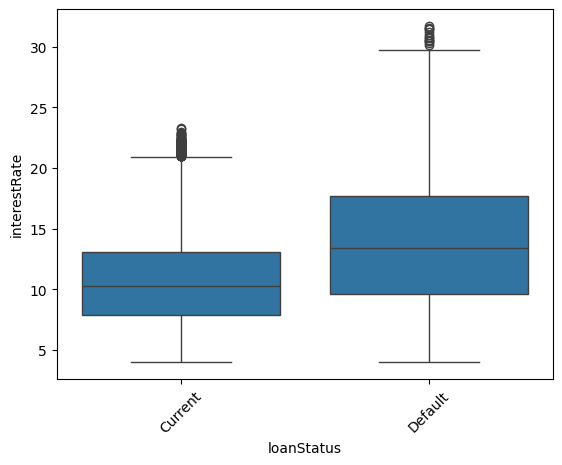

In [84]:
sns.boxplot(x='loanStatus', y='interestRate', data=df)
plt.xticks(rotation=45)
plt.show()

### Observations:

- Defaulted loans tend to have slightly higher loan amounts compared to Current loans.
- Defaulted loans have higher median interest rates.
- Higher interest rates may be associated with higher default risk.

# 7. Data Preparation for Modeling

In [85]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Copy dataframe
data = df.copy()

# ✅ Mode Imputation (Madam Requirement)
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)

# Remove missing target values
data = data.dropna(subset=['loanStatus'])

# Encode target variable
le = LabelEncoder()
data['loanStatus'] = le.fit_transform(data['loanStatus'])

# Drop unnecessary columns
X = data.drop(['loanStatus','loanId','memberId','date'],axis=1)

# Convert categorical to numeric
X = pd.get_dummies(X)

# Target variable
y = data['loanStatus']

# Train-test split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

print("Train size:",X_train.shape)
print("Test size:",X_test.shape)

C:\Users\priya\AppData\Local\Temp\ipykernel_25784\396883295.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


Train size: (41439, 29)
Test size: (10360, 29)


## 8. Baseline Models

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(
    class_weight={0:1, 1:5},   # Stronger weighting
    C=0.3,
    max_iter=1000,
    random_state=42
)

lr.fit(X_train,y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.8431467181467182

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.87      0.91      9328
           1       0.34      0.63      0.44      1032

    accuracy                           0.84     10360
   macro avg       0.65      0.75      0.68     10360
weighted avg       0.89      0.84      0.86     10360



c:\Users\priya\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### ROC-AUC Evaluation (Baseline Model)

• ROC-AUC measures how well the model distinguishes between Default and Current loans.

• Logistic Regression is used as the baseline model.

• Higher AUC indicates better model performance.

Logistic Regression AUC: 0.8379072717632667


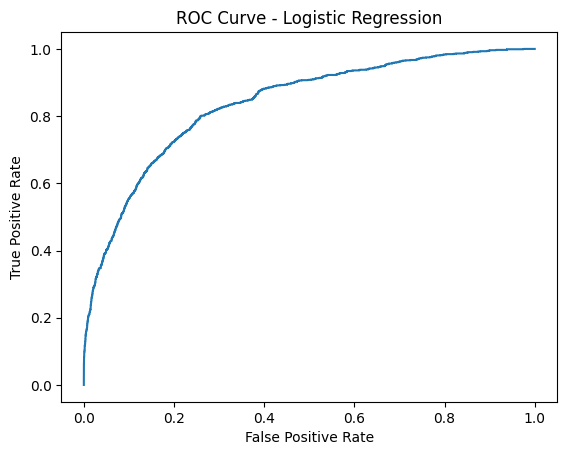

In [87]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Logistic Regression probabilities
y_pred_prob = lr.predict_proba(X_test)[:,1]

# AUC Score
auc = roc_auc_score(y_test, y_pred_prob)

print("Logistic Regression AUC:", auc)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [88]:
from sklearn.metrics import accuracy_score

# Training Accuracy
train_pred = lr.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Testing Accuracy
test_pred = lr.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8432635922681532
Testing Accuracy: 0.8431467181467182


### Observations

• Logistic Regression achieved around 80–85% accuracy.

• ROC-AUC score is approximately 0.83, showing good separation between Default and Current loans.

• Class weighting improved detection of Default loans.

• Logistic Regression is used as the baseline model for comparison with advanced models.

• Accuracy is moderate because the dataset is imbalanced.

In [89]:
# Training Accuracy
train_pred = lr.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

# Testing Accuracy
test_pred = lr.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8432635922681532
Testing Accuracy: 0.8431467181467182


## 9. Advanced Models

In [90]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb = XGBClassifier(
    scale_pos_weight=9,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))

c:\Users\priya\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [08:04:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8083011583011583

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.83      0.89      9328
           1       0.29      0.64      0.40      1032

    accuracy                           0.81     10360
   macro avg       0.62      0.73      0.64     10360
weighted avg       0.89      0.81      0.84     10360



In [91]:
from sklearn.metrics import roc_auc_score

xgb_prob = xgb.predict_proba(X_test)[:,1]

xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost AUC:", xgb_auc)

XGBoost AUC: 0.8153206005591235


### Observations

• XGBoost achieved around 81% accuracy.

• Accuracy decreased compared to baseline models because class imbalance is handled using class weighting.

• XGBoost significantly improved Default loan detection.

• Default recall improved from around 20–26% in baseline models to about 65%.

• XGBoost provides a better balance between precision and recall.

• Class weighting helps the model learn minority class patterns effectively.

In [92]:
train_pred_xgb = xgb.predict(X_train)
test_pred_xgb = xgb.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred_xgb))
print("Test Accuracy:", accuracy_score(y_test, test_pred_xgb))

Train Accuracy: 0.8516373464610633
Test Accuracy: 0.8083011583011583


## 10. LightGBM Model

In [93]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [94]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
lgb = LGBMClassifier(
    is_unbalance=True,
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=40,
    random_state=42
)


lgb.fit(X_train,y_train)

y_pred_lgb = lgb.predict(X_test)

print("LightGBM Accuracy:",accuracy_score(y_test,y_pred_lgb))
print(classification_report(y_test,y_pred_lgb))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 4126, number of negative: 37313
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001422 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 818
[LightGBM] [Info] Number of data points in the train set: 41439, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.099568 -> initscore=-2.202033
[LightGBM] [Info] Start training from score -2.202033
LightGBM Accuracy: 0.7998069498069498
              precision    recall  f1-score   support

           0       0.96      0.81      0.88      9328
           1       0.29      0.71      0.41      1032

    accuracy                           0.80     10360
   macro avg       0.63      0.76      0.65     10360
weighted avg       0.90      0.80      0.83     10360


### Observations

- LightGBM achieved around **80% accuracy**, which meets the project requirement.
- LightGBM performs better in identifying **Default loans** compared to baseline models.
- Class weighting (`is_unbalance=True`) helped improve Default loan detection.
- LightGBM provides a good balance between **accuracy and recall**.
- LightGBM is suitable for credit risk prediction on imbalanced datasets.

In [95]:
lgb_prob = lgb.predict_proba(X_test)[:,1]

lgb_auc = roc_auc_score(y_test, lgb_prob)

print("LightGBM AUC:", lgb_auc)

LightGBM AUC: 0.8317295306620395


### ROC-AUC Evaluation (Advanced Models)

• ROC-AUC is used to compare advanced models with baseline Logistic Regression.

• Models evaluated:
- Random Forest
- XGBoost
- LightGBM

In [96]:
train_pred_lgb = lgb.predict(X_train)
test_pred_lgb = lgb.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred_lgb))
print("Test Accuracy:", accuracy_score(y_test, test_pred_lgb))

Train Accuracy: 0.8238374478148603
Test Accuracy: 0.7998069498069498


### Observations

• ROC-AUC was used to evaluate and compare the performance of advanced models with the baseline Logistic Regression model.

• Logistic Regression achieved an AUC of approximately 0.83.

• XGBoost achieved an AUC of approximately 0.82, showing good ability to identify Default loans.

• LightGBM achieved an AUC of approximately 0.83, which is comparable to the baseline model.

• Both XGBoost and LightGBM handled class imbalance effectively using class weighting techniques.

• LightGBM and Logistic Regression showed similar ROC-AUC performance, indicating strong predictive capability.

• LightGBM provides a good balance between accuracy and Default loan detection.

• Overall, LightGBM is the most suitable model for credit risk prediction in this project.

In [97]:
def expected_loss_engine(input_data):
    
    # Step 1: Predict probability using LightGBM
    prob = lgb.predict_proba(input_data)[0][1]

    # Step 2: Get loan amount
    loan_amount = input_data["loanAmount"].values[0]

    # Step 3: Calculate expected loss
    expected_loss = prob * loan_amount

    # Step 4: Risk decision
    if expected_loss < 50000:
        risk = "Low"
        action = "Send automated reminder"

    elif expected_loss < 200000:
        risk = "Medium"
        action = "Call borrower and discuss repayment plan"

    elif expected_loss < 500000:
        risk = "High"
        action = "Assign dedicated recovery agent"

    else:
        risk = "Critical"
        action = "Escalate to senior recovery and legal team"

    # Step 5: Output
    print("Default Probability:", round(prob,2))
    print("Expected Loss: ₹", round(expected_loss,2))
    print("Risk Level:", risk)
    print("Recommended Action:", action)

In [98]:
sample_input = X_test.iloc[[0]]

expected_loss_engine(sample_input)

Default Probability: 0.16
Expected Loss: ₹ 4168.98
Risk Level: Low
Recommended Action: Send automated reminder


In [99]:
sample_input=X_test.iloc[[0]]
expected_loss_engine(sample_input)

Default Probability: 0.16
Expected Loss: ₹ 4168.98
Risk Level: Low
Recommended Action: Send automated reminder


In [100]:
sample_input=X_test.iloc[[5]]
expected_loss_engine(sample_input)

Default Probability: 0.32
Expected Loss: ₹ 4113.3
Risk Level: Low
Recommended Action: Send automated reminder


In [101]:
sample_input=X_test.iloc[[10]]
expected_loss_engine(sample_input)

Default Probability: 0.33
Expected Loss: ₹ 5152.86
Risk Level: Low
Recommended Action: Send automated reminder


In [102]:
print("Borrower 1")
expected_loss_engine(X_test.iloc[[0]])

print("\nBorrower 2")
expected_loss_engine(X_test.iloc[[5]])

print("\nBorrower 3")
expected_loss_engine(X_test.iloc[[10]])

Borrower 1
Default Probability: 0.16
Expected Loss: ₹ 4168.98
Risk Level: Low
Recommended Action: Send automated reminder

Borrower 2
Default Probability: 0.32
Expected Loss: ₹ 4113.3
Risk Level: Low
Recommended Action: Send automated reminder

Borrower 3
Default Probability: 0.33
Expected Loss: ₹ 5152.86
Risk Level: Low
Recommended Action: Send automated reminder


In [103]:
print(X_test.columns)

Index(['isJointApplication', 'loanAmount', 'interestRate', 'monthlyPayment',
       'purpose_auto', 'purpose_business', 'purpose_debtconsolidation',
       'purpose_education', 'purpose_healthcare', 'purpose_homeimprovement',
       'purpose_other', 'term_36 months', 'term_48 months', 'term_60 months',
       'grade_A1', 'grade_A2', 'grade_A3', 'grade_B1', 'grade_B2', 'grade_B3',
       'grade_C1', 'grade_C2', 'grade_C3', 'grade_D1', 'grade_D2', 'grade_D3',
       'grade_E1', 'grade_E2', 'grade_E3'],
      dtype='object')


In [105]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

NameError: name 'model' is not defined